## 1. Load packages

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import sys
import os
from UniProtMapper import ProtMapper
# get project root (two levels up from this notebook)
project_root = os.path.abspath(os.path.join(os.path.dirname('src'), '..'))
# if in notebook:
# project_root = os.path.abspath('..')   # or adjust as needed

if project_root not in sys.path:
    sys.path.insert(0, project_root)
from importlib import reload

/mnt/aiongpfs/users/adhal/micromamba/envs/scrna_target_idf/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## 2. Load scHIIT packages

In [2]:
import src.methods.schiit_method.tf_filters.base_filter as schiit_base
import src.methods.schiit_method.tf_filters.jsd_filter as schiit_main
import src.methods.schiit_method.network.grn_base as schiit_grn
reload(schiit_main)
reload(schiit_grn)

<module 'src.methods.schiit_method.network.grn_base' from '/mnt/scratch/users/adhal/SingleCellUtils/src/methods/schiit_method/network/grn_base.py'>

##  3. Load data method creation for query + reference data 

- reference data: single nuclei data
- query data: seattle AD data

In [3]:
ref_data_path = "/mnt/lscratch/users/adhal/SingleCellUtils/data/scHIIT_ref/ref_nuclei_231125.h5ad"
query_data_path = "/mnt/lscratch/users/adhal/SingleCellUtils/data/scHIIT_query/neuronal/sead/sead_sampled_10K_171125.h5ad"
ref_adata = sc.read_h5ad(ref_data_path)
query_adata = sc.read_h5ad(query_data_path)

In [9]:
query_adata.var_names

Index(['ENSG00000000003', 'ENSG00000000005', 'ENSG00000000419',
       'ENSG00000000457', 'ENSG00000000460', 'ENSG00000000938',
       'ENSG00000000971', 'ENSG00000001036', 'ENSG00000001084',
       'ENSG00000001167',
       ...
       'ENSG00000288616', 'ENSG00000288631', 'ENSG00000288642',
       'ENSG00000288649', 'ENSG00000288675', 'ENSG00000288701',
       'ENSG00000288702', 'ENSG00000288705', 'ENSG00000288709',
       'ENSG00000288722'],
      dtype='object', length=36412)

In [10]:
ref_adata.var_names

Index(['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1', 'A2ML1', 'A2MP1',
       'A3GALT2', 'A4GALT', 'A4GNT',
       ...
       'ZWILCH', 'ZWINT', 'ZXDA', 'ZXDB', 'ZXDC', 'ZYG11A', 'ZYG11B', 'ZYX',
       'ZZEF1', 'ZZZ3'],
      dtype='object', length=22298)

## 4. Function to load from h5ad and harmonize the observation columns

In [5]:
import src.io.seattle_ad.query_ref_merge as query_ref_merge

In [6]:
query_adata_fixed =  query_ref_merge.fix_query_var_names(query_adata)
# ============================================================================
# USAGE
# ============================================================================
# STEP 1: Merge
merged_adata =  query_ref_merge.merge_query_reference_simple(
    query_adata=query_adata_fixed,
    reference_adata=ref_adata,
    query_cluster_key='Class',  # Options: 'Class', 'Subclass', 'Supertype'
    batch_key='dataset'
)


# STEP 2: Verify
query_ref_merge.verify_merge(merged_adata, batch_key='dataset')


# STEP 4: Save
# merged_adata.write('merged_seattle_tabsap.h5ad')
print("\nMerged data ready for benchmarking! ✓")

# STEP 5: Ready to use with base class
print("\n" + "="*60)
print("USAGE WITH BENCHMARKING METHODS")
print("="*60)
del query_adata_fixed


New var_names (first 5):
Index(['TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'C1orf112'], dtype='object')

Duplicate genes that got suffix:
Index(['NKX3-2', 'NKX2-3', 'H1-3', 'H1-1', 'NKX2-4', 'NKX2-2', 'NKX2-8',
       'NKX2-1', 'ERVK3-1', 'NKX6-2'],
      dtype='object')
MERGING QUERY + REFERENCE (Reference has no metadata)

Step 1: Finding common genes...
  Query genes:     36,412
  Reference genes: 22,298
  Common genes:    20,745

Step 2: Adding metadata...
  Query clusters: 2
  Reference: all labeled as 'background'

Step 3: Preserving query metadata...
  Query-specific columns: 38

Step 4: Aligning gene metadata...

Step 5: Concatenating datasets...

MERGE COMPLETE
Total cells:      181,349
Total genes:      20,745
Query cells:      17,937
Reference cells:  163,412

Query cluster distribution:
  Neuronal: GABAergic: 9,200 cells
  Neuronal: Glutamatergic: 8,737 cells

VERIFICATION

1. Basic structure:
   Total cells: 181,349
   Total genes: 20,745
   Sparse matrix: True

2. Dataset distri

## 5. Apply scHIIT

In [7]:
reload(schiit_main)
reload(schiit_base)

<module 'src.methods.schiit_method.tf_filters.base_filter' from '/mnt/scratch/users/adhal/SingleCellUtils/src/methods/schiit_method/tf_filters/base_filter.py'>

In [48]:
import numpy as np
import gc
from scipy.sparse import csr_matrix, issparse

# Create memory-safe subset (subsample background)
def create_subset(adata, target_ct, max_background=20000):
    target_mask = adata.obs['Class'] == target_ct
    background_mask = adata.obs['Class'] == 'background'
    
    target_idx = np.where(target_mask)[0]
    background_idx = np.where(background_mask)[0]
    
    if len(background_idx) > max_background:
        np.random.seed(42)
        background_idx = np.random.choice(background_idx, max_background, replace=False)
    
    keep_idx = np.concatenate([target_idx, background_idx])
    subset = adata[keep_idx, :].copy()
    
    if not issparse(subset.X):
        subset.X = csr_matrix(subset.X)
    
    return subset

# Run pipeline
reload(schiit_main)
results, stageI_II_tfs = {}, {}

tf_df = pd.read_csv('/mnt/lscratch/users/adhal/data/scrna_target_idf_v2/scrna_target_idf_v2/data/Homo_sapiens_TF.txt', sep='\t')
tf_name_list = tf_df['Symbol'].to_list()

ct = 'Neuronal: GABAergic'
adata_safe = create_subset(merged_adata, ct, max_background=50000)

In [ ]:
for method in ['extended_gjsd']:
    neuro_top_tf = schiit_main.CoreFilterOnlyPipeline(
        adata=adata_safe,  # Use subset
        tf_list=tf_name_list,
        target_cell_type=ct,
        background_cell_type='background',
        cell_type_key='Class',
        chipseq_file=None,
        verbose=True,
        scgx_sig_file=None,
        main_filter='unique_only',
        jsd_method=method,
        top_n_high=None,
        top_jsd_pc=None,
        top_n_jsd=500,
        expr_method=None,
    
    )
    
    neuro_top_tf.run()
    results[method] = neuro_top_tf.results
    stageI_II_tfs[method] = neuro_top_tf.results['core_filtered_tfs']

del adata_safe
gc.collect()

  Converting sparse matrix for parallel processing...
INITIALIZED: CoreFilterOnlyPipeline
Target cell type: Neuronal: GABAergic
Target cells: 9200
Total cells: 59200
Input TFs: 1659

RUNNING: CoreFilterOnlyPipeline

[Core Filtering]
  Computing geometric_jsd divergence for 1542 TFs...
    Using 8 processes for 1542 genes...


    Parallel geometric_jsd: 100%|██████████| 1542/1542 [00:17<00:00, 88.29it/s] 


  Top 500 TFs (geometric_jsd <= 8821.919)
  Unique expression TFs: 500/1542
  Top 5 by geometric_jsd (most specific): HELT(0.00), FOXD4L3(0.00), PEG3(1617.62), MYT1L(2349.90), ZNF655(3300.40)
Core filtered TFs (high & unique): 500

[Additional Filtering]
  No additional filtering applied
  Final filtered TFs: 500

[Network Construction]
  No network built (baseline uses core filters only)
  Network: 500 nodes, 0 edges

[Identity TF Selection]
  Identity TFs found: 100

RESULTS SUMMARY

Filtering Cascade:
  Input TFs:        1659
  ├─ High expr:     1659
  ├─ Unique expr:    500
  ├─ Core (both):    500
  └─ Final:          500

Network:
  Nodes:             500
  Edges:               0

Identity TFs:
  Found:             100

Runtime: 22.83s
  Converting sparse matrix for parallel processing...
INITIALIZED: CoreFilterOnlyPipeline
Target cell type: Neuronal: GABAergic
Target cells: 9200
Total cells: 59200
Input TFs: 1659

RUNNING: CoreFilterOnlyPipeline

[Core Filtering]
  Computing ext

    Parallel extended_gjsd: 100%|██████████| 1542/1542 [00:00<00:00, 4012.44it/s]


  Top 500 TFs (extended_gjsd <= 11697.888)
  Unique expression TFs: 500/1542
  Top 5 by extended_gjsd (most specific): HELT(0.00), HOXB3(0.00), TFAP2B(0.00), IRX3(0.00), HAND2(0.00)
Core filtered TFs (high & unique): 500

[Additional Filtering]
  No additional filtering applied
  Final filtered TFs: 500

[Network Construction]
  No network built (baseline uses core filters only)
  Network: 500 nodes, 0 edges

[Identity TF Selection]
  Identity TFs found: 100

RESULTS SUMMARY

Filtering Cascade:
  Input TFs:        1659
  ├─ High expr:     1659
  ├─ Unique expr:    500
  ├─ Core (both):    500
  └─ Final:          500

Network:
  Nodes:             500
  Edges:               0

Identity TFs:
  Found:             100

Runtime: 5.60s


66066

In [ ]:
results_genes = {}
stageI_II_genes = {}
gene_list = list(set(adata_safe.var_names) - set(tf_name_list))
for method in [ 'extended_gjsd']:
    neuro_top_genes = schiit_main.CoreFilterOnlyPipeline(
        adata=adata_safe,  # Use subset
        tf_list=gene_list,
        target_cell_type=ct,
        background_cell_type='background',
        cell_type_key='Class',
        chipseq_file=None,
        verbose=True,
        scgx_sig_file='/mnt/lscratch/users/adhal/SingleCellUtils/outputs/scGX/tier1_SEAD/sig_frames/Neuronal: GABAergic_sig_tbl.txt',
        main_filter='high_and_unique',
        jsd_method=method,
        top_n_high=700,
        top_jsd_pc=None,
        top_n_jsd=30,
        expr_method='scgx',
    
    )
    
    neuro_top_genes.run()
    results_genes[method] = neuro_top_genes.results
    stageI_II_genes[method] = neuro_top_genes.results['core_filtered_tfs']

del adata_safe
gc.collect()

  Converting sparse matrix for parallel processing...
INITIALIZED: CoreFilterOnlyPipeline
Target cell type: Neuronal: GABAergic
Target cells: 9200
Total cells: 59200
Input TFs: 19203

RUNNING: CoreFilterOnlyPipeline

[Core Filtering]
  High expression TFs: 6085/19203
  Computing geometric_jsd divergence for 6085 TFs...
    Using 8 processes for 6085 genes...


    Parallel geometric_jsd: 100%|██████████| 6085/6085 [01:09<00:00, 87.15it/s] 


  Top 30 TFs (geometric_jsd <= 2533.788)
  Unique expression TFs: 30/6085
  Top 5 by geometric_jsd (most specific): NANOS2(0.00), DLGAP2(682.31), MIR124-1HG(951.66), SH3GL3(1017.01), KCNC2(1034.76)
Core filtered TFs (high & unique): 30

[Additional Filtering]
  No additional filtering applied
  Final filtered TFs: 30

[Network Construction]
  No network built (baseline uses core filters only)
  Network: 30 nodes, 0 edges

[Identity TF Selection]
  Identity TFs found: 20

RESULTS SUMMARY

Filtering Cascade:
  Input TFs:        19203
  ├─ High expr:     6085
  ├─ Unique expr:     30
  ├─ Core (both):     30
  └─ Final:           30

Network:
  Nodes:              30
  Edges:               0

Identity TFs:
  Found:              20

Runtime: 81.00s
  Converting sparse matrix for parallel processing...
INITIALIZED: CoreFilterOnlyPipeline
Target cell type: Neuronal: GABAergic
Target cells: 9200
Total cells: 59200
Input TFs: 19203

RUNNING: CoreFilterOnlyPipeline

[Core Filtering]
  High expr

    Parallel extended_gjsd: 100%|██████████| 6085/6085 [00:01<00:00, 4066.57it/s]


  Top 30 TFs (extended_gjsd <= 122.368)
  Unique expression TFs: 30/6085
  Top 5 by extended_gjsd (most specific): NANOS2(0.00), BSCL2(13.99), FXYD6(20.03), POLR2J3(20.98), HCG18(24.43)
Core filtered TFs (high & unique): 30

[Additional Filtering]
  No additional filtering applied
  Final filtered TFs: 30

[Network Construction]
  No network built (baseline uses core filters only)
  Network: 30 nodes, 0 edges

[Identity TF Selection]
  Identity TFs found: 20

RESULTS SUMMARY

Filtering Cascade:
  Input TFs:        19203
  ├─ High expr:     6085
  ├─ Unique expr:     30
  ├─ Core (both):     30
  └─ Final:           30

Network:
  Nodes:              30
  Edges:               0

Identity TFs:
  Found:              20

Runtime: 12.48s


875

## Check how good the results are with trackplots

In [17]:
all_jsd_res = {}
for method in ['geometric_jsd', 'extended_gjsd']:
    all_jsd = pd.Series(results[method]['jsd_scores']).reset_index()
    all_jsd.columns = ['TF', 'score']
    all_jsd_res[method] = all_jsd

In [37]:
all_jsd_res_genes = {}
for method in ['geometric_jsd', 'extended_gjsd']:
    all_jsd = pd.Series(results_genes[method]['jsd_scores']).reset_index()
    all_jsd.columns = ['TF', 'score']
    all_jsd_res_genes[method] = all_jsd

In [18]:
all_jsd_res['geometric_jsd'].sort_values(['score'])

,TF,score
59,PEG3,1617.615593
1,MYT1L,2349.904255
138,ZNF655,3300.397088
139,ZNF506,4071.542710
11,ZNF536,4273.505976
...,...,...
57,BAZ2B,25251.485789
12,TCF12,25490.518523
133,SON,25893.601565
69,FOXO3,26431.530351


In [19]:
all_jsd_res['extended_gjsd'].sort_values(['score'])

,TF,score
59,PEG3,9.408139e+00
274,ZNF709,2.219490e+01
238,DLX1,5.829125e+01
184,ZNF587B,6.870760e+01
231,ZSCAN26,8.183466e+01
...,...,...
123,NFIA,4.656354e+05
420,SP1,6.308191e+05
329,CREB5,9.657845e+05
128,ETV6,1.451527e+06


In [45]:
all_jsd_res['extended_gjsd'].to_csv('./gaba_tfs_for_enrich_111225.csv')
all_jsd_res_genes['extended_gjsd'].to_csv('./gaba_genes_for_enrich_111225.csv')

## 6. Check the Unique TF and Gene Distributions

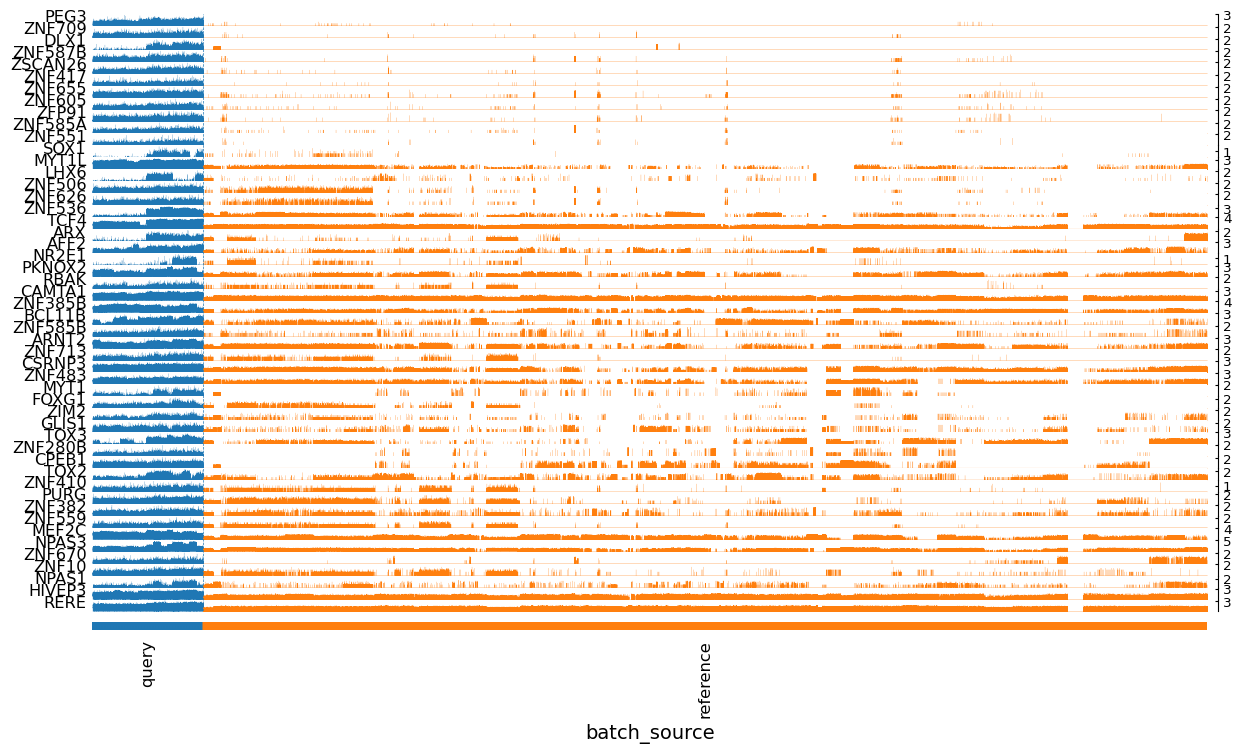

In [51]:
import matplotlib.pyplot as plt
# Set font sizes before plotting
plt.rcParams['font.size'] = 14  # Base font size
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

ax = sc.pl.tracksplot(
    merged_adata, 
    all_jsd_res['extended_gjsd'].sort_values(['score'])['TF'].to_list()[:50], 
    groupby="batch_source", 
    dendrogram=False, 
    figsize=(15, 8),
    show=False
)
plt.show()

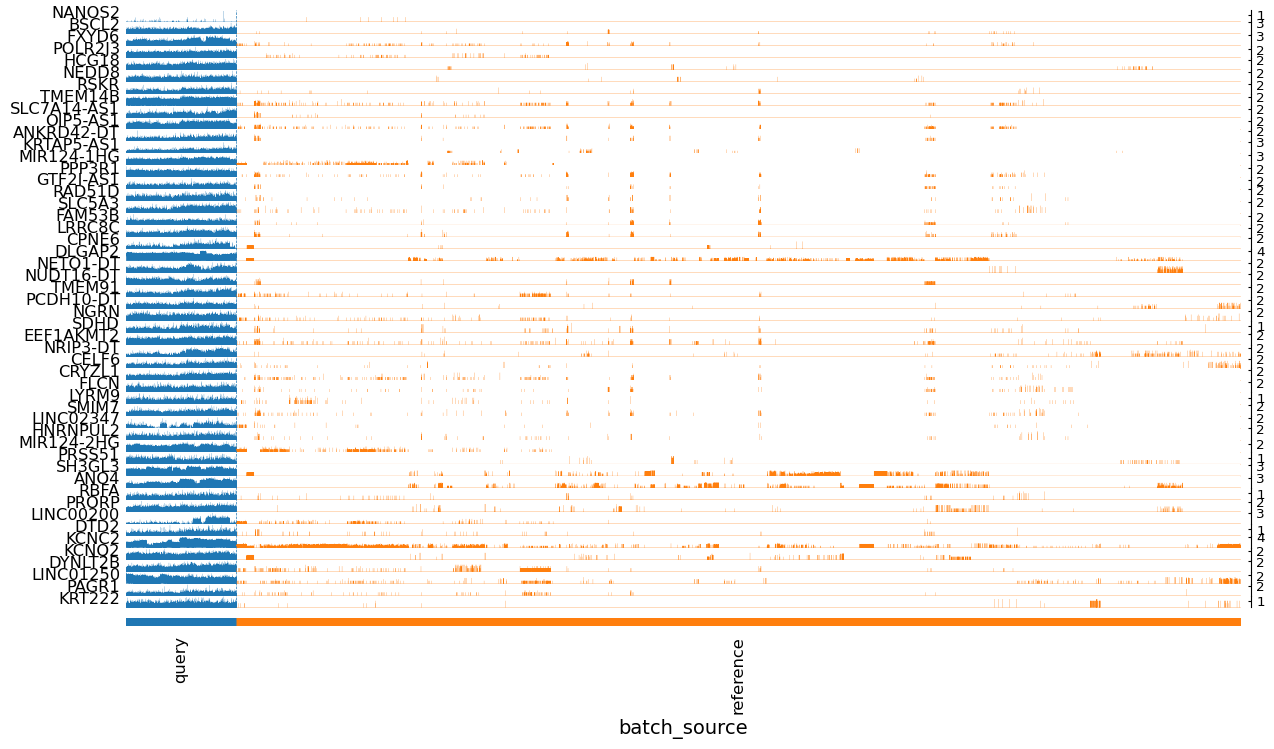

In [41]:
import matplotlib.pyplot as plt
# Set font sizes before plotting
plt.rcParams['font.size'] = 14  # Base font size
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

ax = sc.pl.tracksplot(
    merged_adata, 
    all_jsd_res_genes['extended_gjsd'].sort_values(['score'])['TF'].to_list()[:50], 
    groupby="batch_source", 
    dendrogram=False, 
    figsize=(15, 8),
    show=False
)
plt.show()

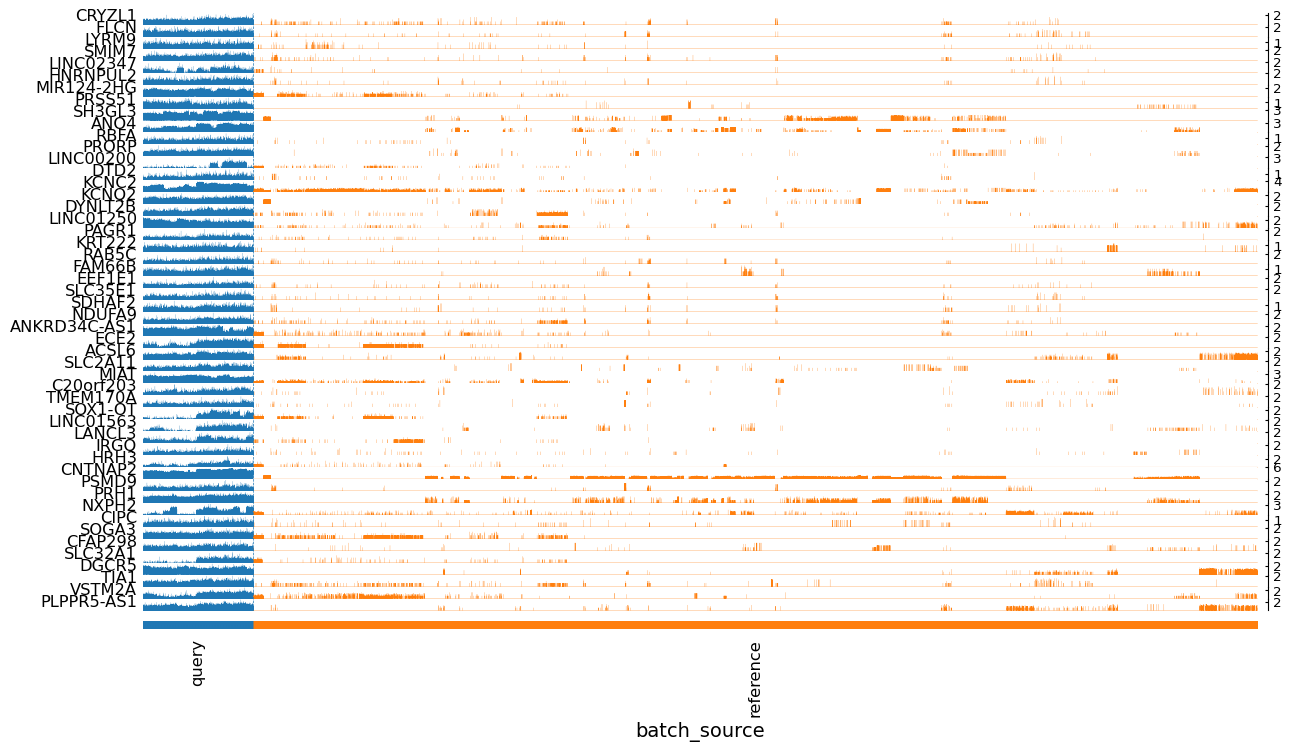

In [42]:
import matplotlib.pyplot as plt
# Set font sizes before plotting
plt.rcParams['font.size'] = 14  # Base font size
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

ax = sc.pl.tracksplot(
    merged_adata, 
    all_jsd_res_genes['extended_gjsd'].sort_values(['score'])['TF'].to_list()[30:80], 
    groupby="batch_source", 
    dendrogram=False, 
    figsize=(15, 8),
    show=False
)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
# Set font sizes before plotting
plt.rcParams['font.size'] = 14  # Base font size
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

ax = sc.pl.tracksplot(
    merged_adata, 
    all_jsd_res['extended_gjsd'].sort_values(['score'])['TF'].to_list()[:30], 
    groupby="batch_source", 
    dendrogram=False, 
    figsize=(15, 8),
    show=False
)
plt.show()

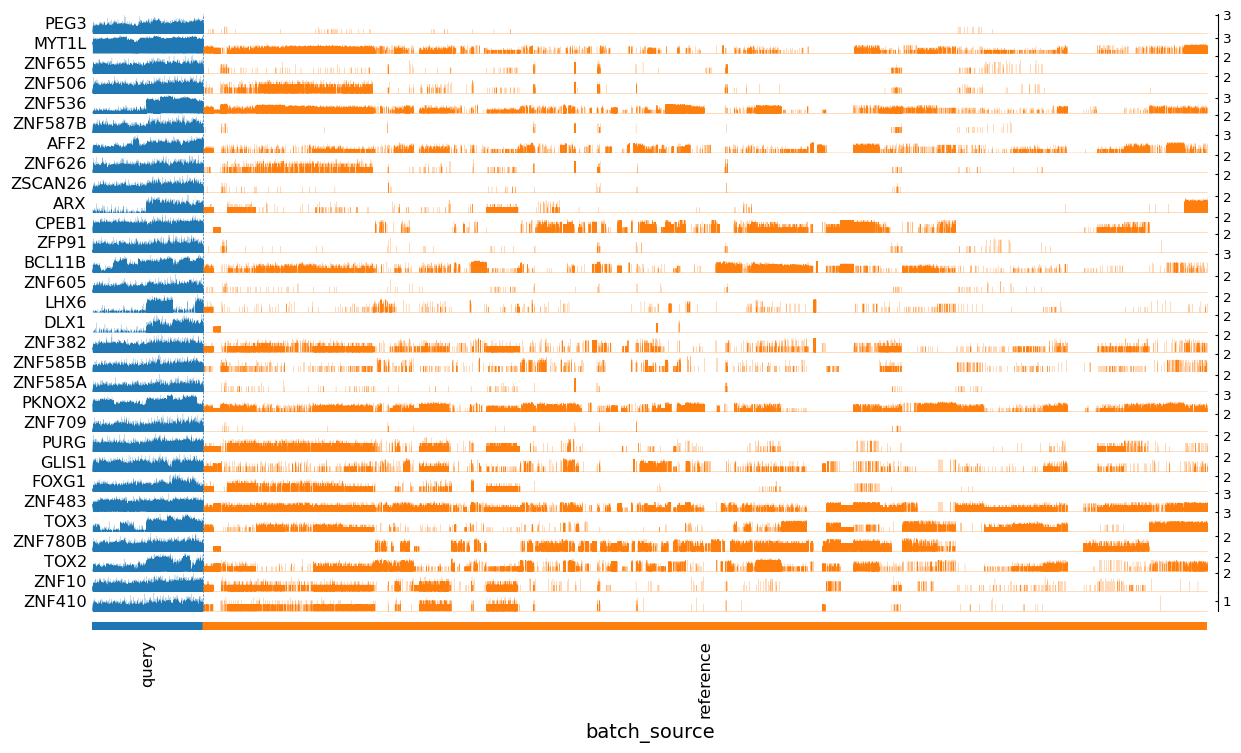

In [21]:
import matplotlib.pyplot as plt
# Set font sizes before plotting
plt.rcParams['font.size'] = 14  # Base font size
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

ax = sc.pl.tracksplot(
    merged_adata, 
    all_jsd_res['geometric_jsd'].sort_values(['score'])['TF'].to_list()[:30], 
    groupby="batch_source", 
    dendrogram=False, 
    figsize=(15, 8),
    show=False
)
plt.show()

## Run GRN to build transcriptional core

In [22]:
chip_seq_file = '/mnt/lscratch/users/adhal/scrna_target_idf_v3/data/from_martin/Chip_removed_overlapped_peaks.tsv'

stage3_results = schiit_grn.run_stage_iii(
    tf_results=results['extended_gjsd'],
    gene_results=results['extended_gjsd'],
    chipseq_file=chip_seq_file,
    selection_method='largest',
    min_scc_size=2,
    output_dir='./stage3_results_20_tfs',
    verbose=True
)


STAGE III: CORE TF IDENTIFICATION

STEP 1: LOAD LITERATURE NETWORK

Loading ChIP-seq: /mnt/lscratch/users/adhal/scrna_target_idf_v3/data/from_martin/Chip_removed_overlapped_peaks.tsv
  ChIP-seq edges: 6844416

Loading CollecTRI...
  CollecTRI edges: 21699

✓ Literature network: 2365733 edges

=== Identifying Connecting TFs ===
  Unique TFs: 30
  Non-unique TFs to evaluate: 435
  Found 101 connecting TFs

  Example connections (first 5):
    ZFHX2:
      Sources (unique TFs): ['BCL11B', 'ZNF605', 'ZFP91']
      Targets (unique TFs): ['CAMTA1', 'ZNF585B', 'ZNF417']
    ZNF737:
      Sources (unique TFs): ['BCL11B', 'TCF4', 'ZFP91']
      Targets (unique TFs): ['ZSCAN26']
    RFX3:
      Sources (unique TFs): ['BCL11B', 'TCF4', 'ZNF605']
      Targets (unique TFs): ['PEG3']
    MECP2:
      Sources (unique TFs): ['BCL11B']
      Targets (unique TFs): ['ZNF585B']
    GLIS1:
      Sources (unique TFs): ['BCL11B']
      Targets (unique TFs): ['CAMTA1', 'ZNF709']

=== Building Regulatory Net

## Plotting TF core network

In [23]:
import src.io.plotting_utils as putils

✓ Network saved to: core_network.png


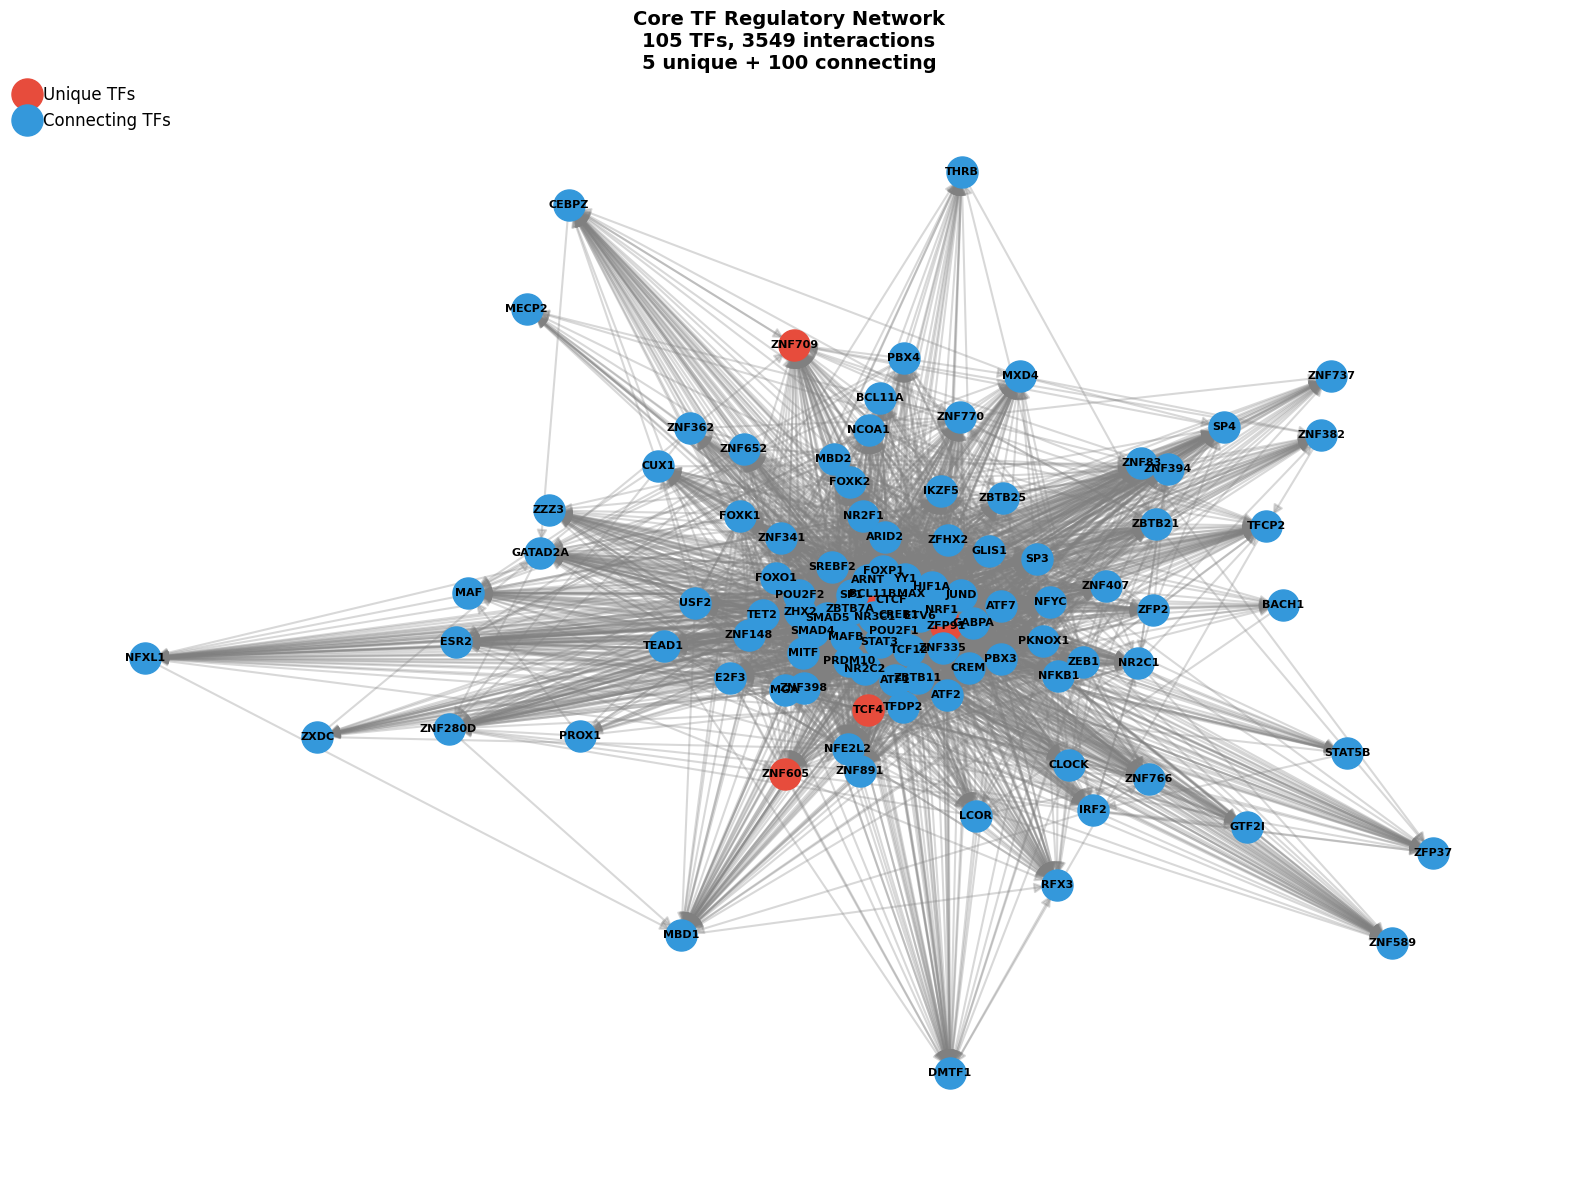

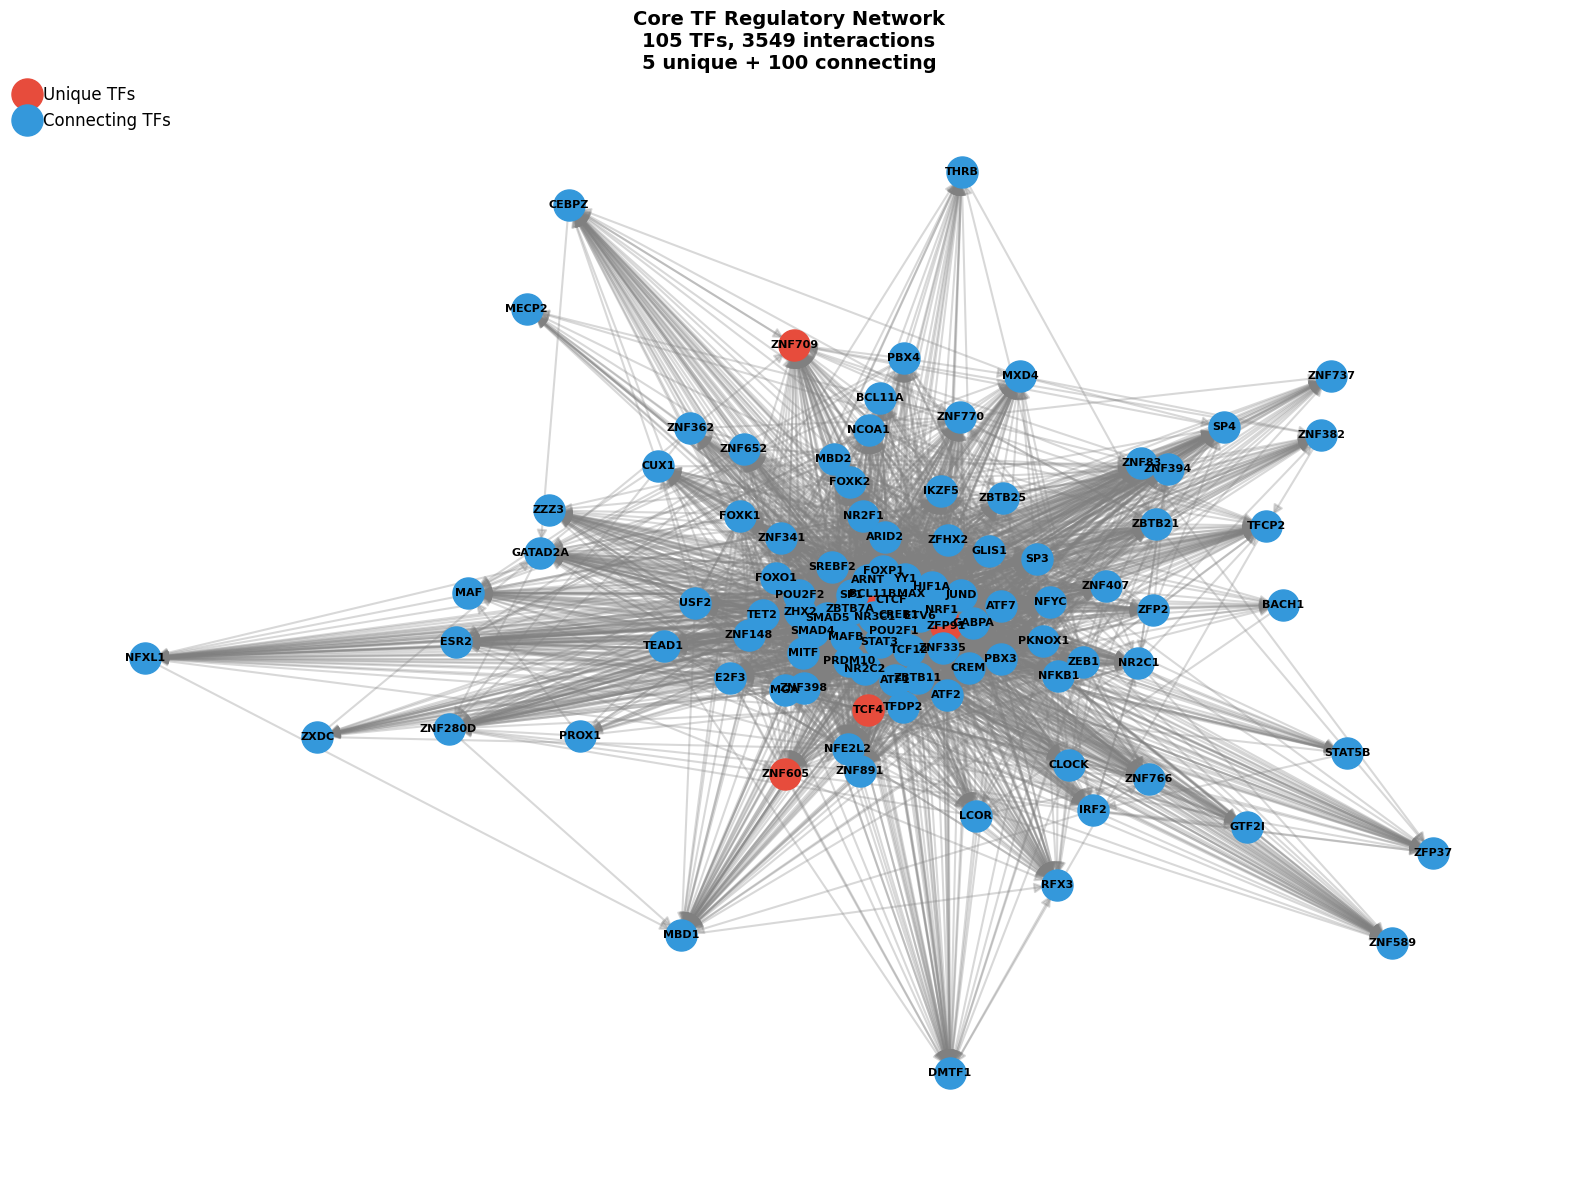

In [24]:
putils.plot_core_network(stage3_results)